In [2]:
import pandas as pd
import numpy as np

# Global formatting: display all floats to 4 decimal places.
pd.options.display.float_format = "{:.4f}".format
np.set_printoptions(precision=4, suppress=True)

df = pd.read_csv('house-prices-advanced-regression-techniques/train.csv', index_col=0)

df = df.sample(1000, random_state=42)

In [3]:
monotonic = [
    'OverallQual',
    'GrLivArea',
    'GarageArea',
    'TotalBsmtSF',
    'KitchenQual',
    #'LotArea',
    #'PoolArea',
    'MiscVal',
    'SalePrice'
]
df = df[monotonic]
quality_map = {
    "Ex": 5,  # Excellent
    "Gd": 4,  # Good
    "TA": 3,  # Typical/Average
    "Fa": 2,  # Fair
    "Po": 1   # Poor
}

df["KitchenQual"] = df["KitchenQual"].map(quality_map)
df.head()


,OverallQual,GrLivArea,GarageArea,TotalBsmtSF,KitchenQual,MiscVal,SalePrice
Id,,,,,,,
893,6,1068,264,1059,3,0,154500
1106,8,2622,712,1463,4,0,325000
414,5,1028,360,1008,3,0,115000
523,6,1664,420,1004,3,0,159000
1037,9,1620,912,1620,5,0,315500


In [4]:
median_saleprice = df['SalePrice'].median()
median_saleprice
#sale price binarized
df['SalePrice'] = (df['SalePrice'] > median_saleprice).astype(int)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
cols_to_scale = [col for col in df.columns if col != 'SalePrice']
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

# XGBoost


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from xgboost import XGBClassifier

X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]


In [6]:
accuracy = round(accuracy_score(y_test, y_pred), 4)
f1 = round(f1_score(y_test, y_pred), 4)
auc = round(roc_auc_score(y_test, y_proba), 4)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 score: {f1:.4f}")
print(f"AUC: {auc:.4f}")


Accuracy: 0.8750
F1 score: 0.8780
AUC: 0.9611


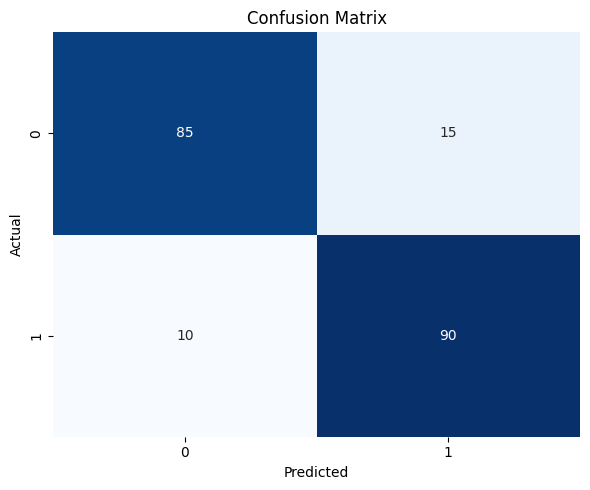

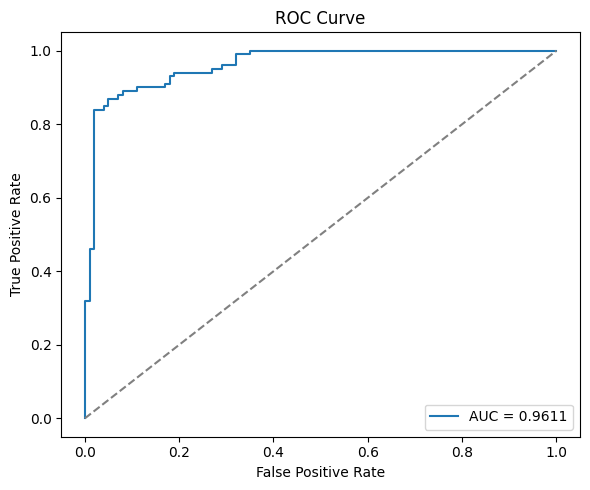

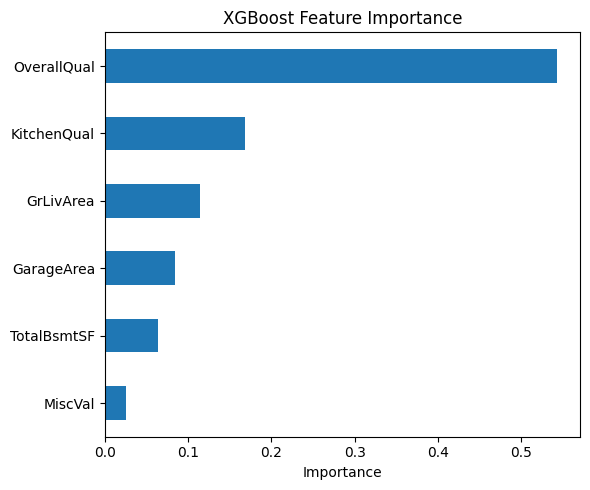

<Figure size 640x480 with 0 Axes>

OverallQual   0.5436
KitchenQual   0.1686
GrLivArea     0.1142
GarageArea    0.0839
TotalBsmtSF   0.0640
MiscVal       0.0257
dtype: float32

In [7]:
# 1) Confusion matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# 2) ROC curve
plt.figure(figsize=(6, 5))
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# 3) Feature importance
plt.figure(figsize=(6, 5))
feature_importance = pd.Series(
    xgb_model.feature_importances_, index=X.columns
).sort_values(ascending=True)
feature_importance.plot(kind='barh')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

feature_importance.sort_values(ascending=False)

### Brief summary
The XGBoost model predicts the binarized SalePrice strong performance in terms of Accuracy, F1, and AUC

Based on the feature-importance plot, variables linked with quality and area contribute most to the predictions, whereas additional field like MiscVal is not important

Confusion matrix confirms high accuracy, recall and precision

AUC close to 1 means the model almost perfectly ranks positive cases higher than negative ones. It shows high True Positive Rate with low False Positive Rate

In [8]:
#choosing samples closer to the decision boundary, because for confident prediction it was not possible to change prediction using only single feature
y_test_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
boundary_indices = np.argsort(np.abs(y_test_pred_proba - 0.5))[:3]
X_test_sample = X_test.iloc[boundary_indices]
X_test_sample

,OverallQual,GrLivArea,GarageArea,TotalBsmtSF,KitchenQual,MiscVal
Id,,,,,,
1384,0.4444,0.2038,0.4062,0.1336,0.6667,0.0000
842,0.4444,0.2270,0.4838,0.1064,0.6667,0.0000
702,0.6667,0.1564,0.3724,0.1905,0.3333,0.0000


In [9]:
y_pred = xgb_model.predict(X_test_sample)
y_proba = xgb_model.predict_proba(X_test_sample)[:, 1]
y_proba

array([0.4948, 0.5071, 0.5102], dtype=float32)

sample with id 100 has low overall quality, kitchen quality and smaller living area and doesn't have garage, hence it is classified as low cost

other samples have higher quality, and have garage, thats  why they are classified as 1


In [28]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_sample)

for i in range(len(X_test_sample)):
    print(f"\nSample {i}")
    print("Prediction:", y_pred[i])
    print("Probability:", y_proba[i])

    sv = shap_values[i]
    contributions = list(zip(X_test_sample.columns, sv))

    # sort by influence
    contributions.sort(key=lambda x: abs(x[1]), reverse=True)

    print("Most influencing features:")
    for f, v in contributions[:5]:
        print(f, v)



Sample 0
Prediction: 0
Probability: 0.49483424
Most influencing features:
OverallQual -1.3986568
KitchenQual 1.1228555
GrLivArea 0.80251247
TotalBsmtSF -0.76532567
GarageArea 0.2194567

Sample 1
Prediction: 1
Probability: 0.507061
Most influencing features:
TotalBsmtSF -1.7333064
GarageArea 1.2652645
OverallQual -1.1669356
KitchenQual 0.8979764
GrLivArea 0.76880324

Sample 2
Prediction: 1
Probability: 0.5101563
Most influencing features:
OverallQual 1.8685137
GrLivArea -1.2533717
KitchenQual -0.9118785
TotalBsmtSF 0.3569939
GarageArea -0.016982073


Sample 0 is slightly pushed toward class 0 due to strong negative impact from OverallQual and TotalBsmtSF, Sample 1 is pushed just over to class 1 mainly by strong positive influence from GarageArea outweighing negatives from TotalBsmtSF and OverallQual, and Sample 2 is classified as 1 because a strong positive contribution from OverallQual outweighs the negative effects of GrLivArea and KitchenQual

Sampling

In [29]:
import numpy as np

def empirical_sampling(model, x_row, eps_values):
    base = model.predict_proba([x_row])[0,1]
    
    results = []
    sv = shap_values[i]
    contributions = list(zip(X_test_sample.columns, sv))
    contributions.sort(key=lambda x: abs(x[1]), reverse=True)
    feature = contributions[0][0]
    print(feature)
    idx = X_test_sample.columns.get_loc(feature)

    for eps in eps_values:
        #all features are gain type
        if base > 0.5:
            sign = -1
        else:
            sign = 1

        x_new = x_row.copy().astype(float)
        x_new[idx] += eps * sign
        
        p = model.predict_proba([x_new])[0,1]
        pred = int(p > 0.5)
        
        results.append((round(eps, 4), round(p, 4), pred))
   
        
        if pred != int(base > 0.5):
            break
    return results

In [30]:
for i in range(len(X_test_sample)):
    print(i)
    x = X_test_sample.iloc[i].values

    eps_values = [0, 0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10, 100, 1000, 10000, 999999999999]

    results = empirical_sampling(xgb_model, x, eps_values)

    for r in results:
        print(r)

0
OverallQual
(0, np.float32(0.4948), 0)
(0.001, np.float32(0.4948), 0)
(0.01, np.float32(0.4948), 0)
(0.05, np.float32(0.4948), 0)
(0.1, np.float32(0.4948), 0)
(0.2, np.float32(0.7559), 1)
1
TotalBsmtSF
(0, np.float32(0.5071), 1)
(0.001, np.float32(0.5071), 1)
(0.01, np.float32(0.4892), 0)
2
OverallQual
(0, np.float32(0.5102), 1)
(0.001, np.float32(0.1239), 0)


# Interpretation

user preferences: Higher overall quality - strongest driver
Larger living space & garage
Better kitchen quality,
user does not care about miscVal

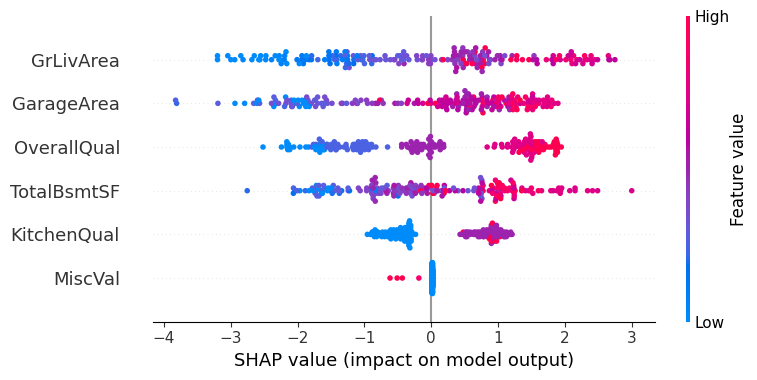

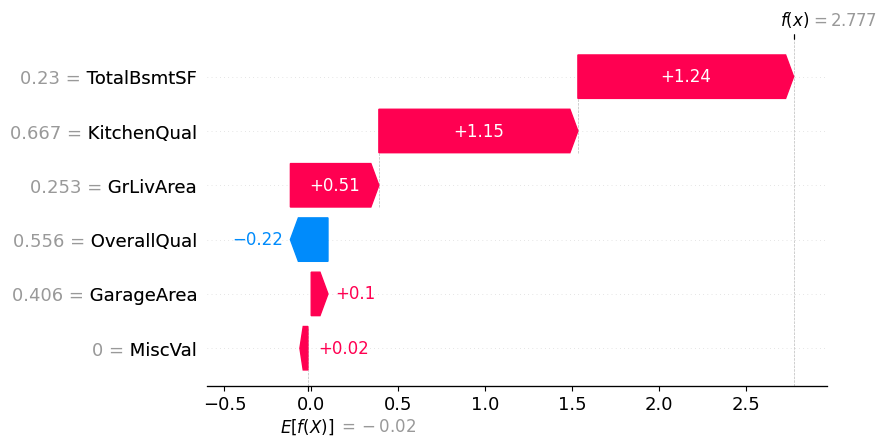

In [13]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

shap.waterfall_plot(shap_values[0])

Every feature is of a gain type and is monotonic

- GrLivArea: Strong positive effect; larger homes increase predictions.
- GarageArea: Positive impact; bigger garages generally raise predictions.
- OverallQual: Very important; higher quality sharply increases predictions.
- TotalBsmtSF: Strong positive effect; larger basements increase predictions.
- KitchenQual: High quality boosts predictions with clear threshold effects.
- MiscVal: Minimal impact; largely irrelevant to predictions.

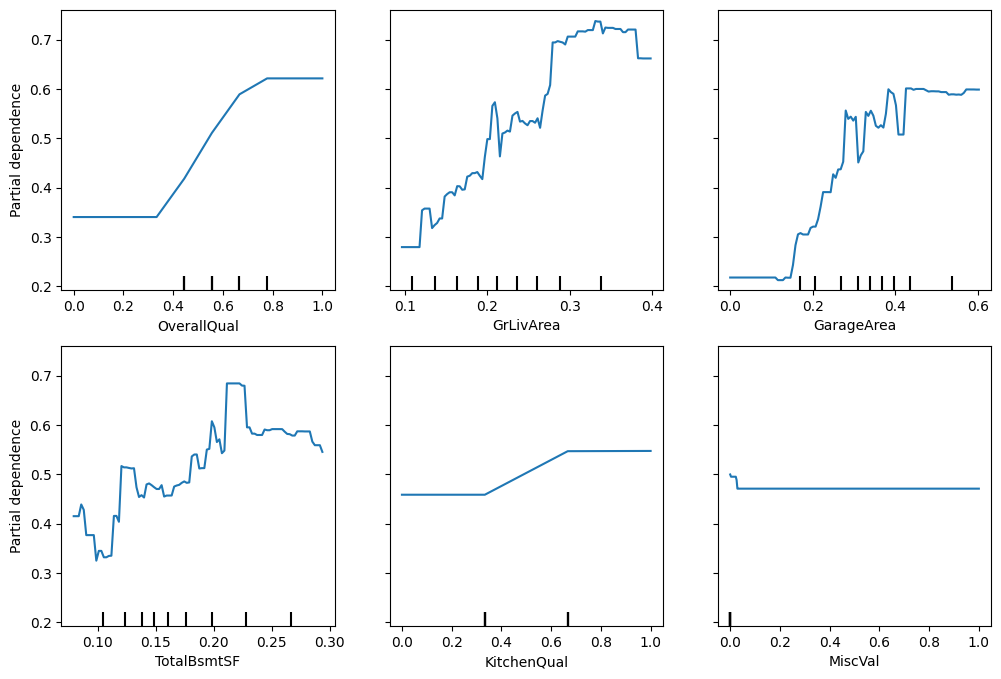

In [14]:
from sklearn.inspection import PartialDependenceDisplay
fig, ax = plt.subplots(figsize=(12, 8))

PartialDependenceDisplay.from_estimator(
    xgb_model,
    X_train,
    [0, 1, 2, 3, 4, 5],
    ax=ax
)

plt.show()

partial dependency plot show how each feature affects the model's prediction on average, while holding other features constant.

- OverallQual: strongest positive effect (very important)
- GrLivArea, GarageArea: increase prediction, then level off
- KitchenQual: step-wise positive impact
- TotalBsmtSF: noisy, weaker/interaction-heavy effect
- MiscVal: no impact

dependencies: TotalBsmtSF is noisy - likely depends on OverallQual or GrLivArea

preference tresholds: 

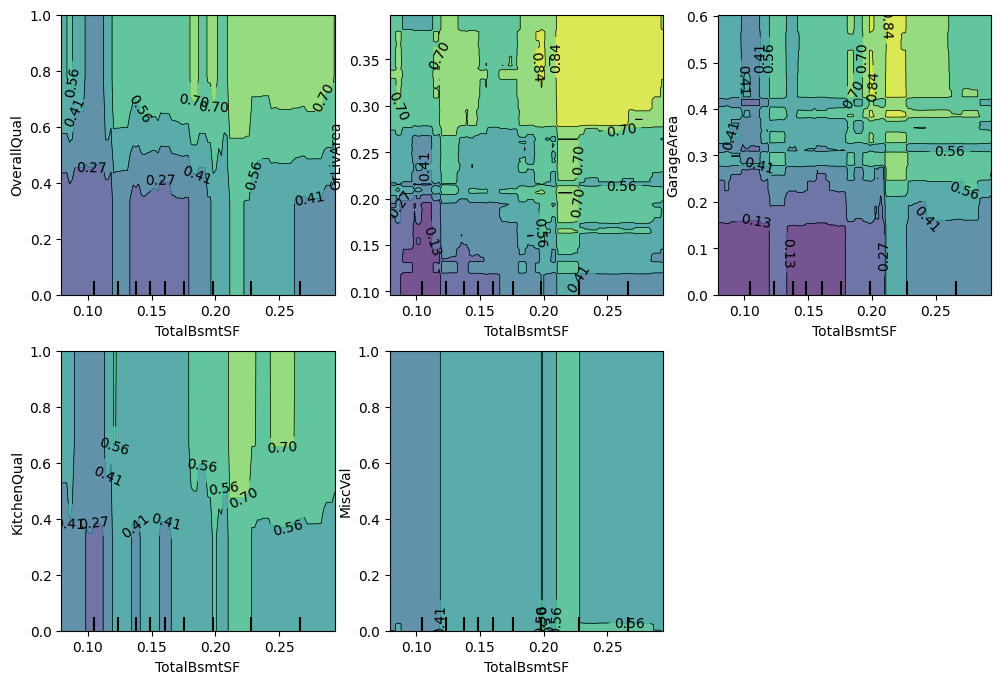

In [15]:
fig, ax = plt.subplots(figsize=(12, 8))

PartialDependenceDisplay.from_estimator(
    xgb_model,
    X_train,
    [(3, i) for i in range(X_train.shape[1]) if i != 3],
    ax=ax,
)

Higher-cost house is likely when basement area is at least moderate, and especially when combined with larger living/garage area and better quality features.
MiscVal is weak and mostly noise in this interaction view.

# ANN-UTA


In [38]:
import sys
from pathlib import Path

import torch

_ROOT = Path.cwd()
_UTA_DIR = _ROOT / "UTA"
if str(_UTA_DIR) not in sys.path:
    sys.path.insert(0, str(_UTA_DIR))

from norm_layer import NormLayer
from uta import Uta

UTA_CHECKPOINT = _UTA_DIR / "uta.pt2"
NUM_HIDDEN = 30

feature_cols_uta = [c for c in df.columns if c != "SalePrice"]
num_criteria_uta = len(feature_cols_uta)

uta_model = Uta(num_criteria_uta, NUM_HIDDEN)
uta_model = NormLayer(uta_model, num_criteria_uta)

ckpt = torch.load(UTA_CHECKPOINT, map_location="cpu")
uta_model.load_state_dict(ckpt["model_state_dict"])

<All keys matched successfully>

In [39]:
_, X_uta_test, _, y_uta_test = train_test_split(
    df[feature_cols_uta],
    df["SalePrice"],
    test_size=0.2,
    random_state=1234,
)
X_uta_test = X_uta_test.head(100)
y_uta_test = y_uta_test.head(100)

In [40]:
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

uta_model.eval()
X_uta = X_uta_test.values.astype("float32").reshape(-1, 1, num_criteria_uta)
X_uta_t = torch.from_numpy(X_uta)

with torch.no_grad():
    uta_scores = uta_model(X_uta_t).numpy()

uta_pred = (uta_scores > 0).astype(int)

print("UTA test accuracy:", round(accuracy_score(y_uta_test, uta_pred), 4))
print("UTA test AUC:", round(roc_auc_score(y_uta_test, uta_scores), 4))
print("UTA test F1:", round(f1_score(y_uta_test, uta_pred), 4))



UTA test accuracy: 0.86
UTA test AUC: 0.9612
UTA test F1: 0.8542


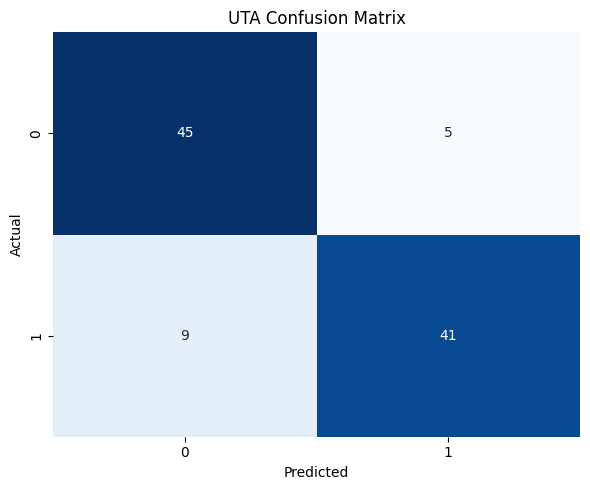

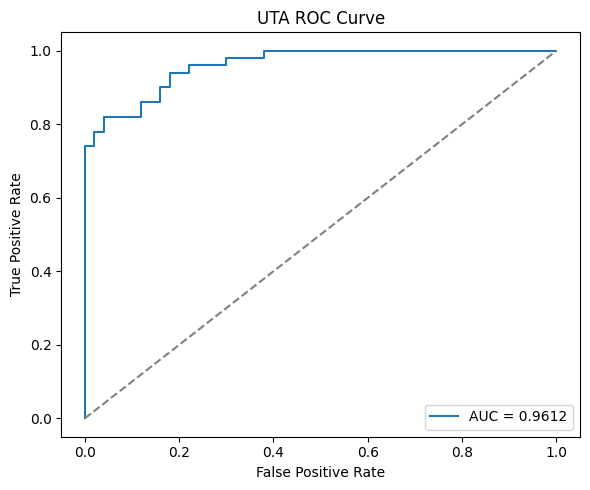

In [41]:
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_uta_test, uta_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False
)
plt.title('UTA Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
fpr, tpr, _ = roc_curve(y_uta_test, uta_scores)
uta_auc = roc_auc_score(y_uta_test, uta_scores)
plt.plot(fpr, tpr, label=f'AUC = {uta_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('UTA ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [42]:
import numpy as np
import shap

# GradientExplainer expects a 2D model output (batch, 1); UTA returns (batch,).
class _UtaShapWrapper(torch.nn.Module):
    def __init__(self, model: torch.nn.Module):
        super().__init__()
        self.model = model

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x).view(-1, 1)


uta_for_shap = _UtaShapWrapper(uta_model).eval()

explainer_uta = shap.GradientExplainer(uta_for_shap, X_uta_t)

shap_values_uta = explainer_uta.shap_values(X_uta_t)
shap_values_uta = np.asarray(shap_values_uta)
X_uta_sample = X_uta_t[:3]

if shap_values_uta.ndim == 4:
    shap_values_uta = shap_values_uta[:, 0, :, 0]

with torch.no_grad():
    uta_scores_sample = uta_for_shap(X_uta_t).numpy().ravel()

uta_pred_sample = (uta_scores_sample > 0).astype(int)

for i in range(len(X_uta_sample)):
    print(f"\nSample {i}")
    print("Prediction (score > 0):", uta_pred_sample[i])
    print("Score (utility - threshold):", uta_scores_sample[i])

    sv = shap_values_uta[i]
    contributions = list(zip(X_uta_test.columns, sv))

    contributions.sort(key=lambda x: abs(x[1]), reverse=True)

    print("Most influencing features:")
    for f, v in contributions[:5]:
        print(f, round(v, 4))
   



Sample 0
Prediction (score > 0): 0
Score (utility - threshold): -0.038960457
Most influencing features:
KitchenQual -0.0357
GarageArea -0.0212
GrLivArea 0.0196
TotalBsmtSF 0.0094
OverallQual 0.0004

Sample 1
Prediction (score > 0): 1
Score (utility - threshold): 0.10751757
Most influencing features:
KitchenQual 0.0498
OverallQual 0.0383
GarageArea 0.0198
TotalBsmtSF 0.0172
GrLivArea -0.0094

Sample 2
Prediction (score > 0): 0
Score (utility - threshold): -0.1312829
Most influencing features:
GarageArea -0.087
KitchenQual -0.0412
OverallQual -0.0285
GrLivArea 0.018
TotalBsmtSF -0.0016


In [43]:
import numpy as np
import torch

def predict_uta_score_and_class(model, x_row):
    x_t = torch.tensor(x_row, dtype=torch.float32).view(1, 1, -1)
    with torch.no_grad():
        score = float(model(x_t).view(-1).item())
    pred = int(score > 0)
    return score, pred


def empirical_sampling_uta(model, x_row, feature_names, sv, eps_values):
    base_score, base_pred = predict_uta_score_and_class(model, x_row)

    contributions = list(zip(feature_names, sv))
    contributions.sort(key=lambda x: abs(x[1]), reverse=True)
    feature, feature_shap = contributions[0]
    idx = feature_names.get_loc(feature)

    direction = -1 if base_pred == 1 else 1

    results = []
    for eps in eps_values:
        x_new = x_row.copy().astype(np.float32)
        x_new[idx] = np.clip(x_new[idx] + eps * direction, 0.0, 1.0)

        score, pred = predict_uta_score_and_class(model, x_new)
        results.append((eps, score, pred))

        if pred != base_pred:
            break

    return {
        "feature": feature,
        "feature_shap": float(feature_shap),
        "base_score": base_score,
        "base_pred": base_pred,
        "direction": direction,
        "results": results,
    }


eps_values = [0, 0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10]

for i in range(len(X_uta_sample)):
    print(f"\nSample {i}")
    x = X_uta_test.iloc[i].values.astype(np.float32)

    out = empirical_sampling_uta(
        uta_model,
        x,
        X_uta_test.columns,
        shap_values_uta[i],
        eps_values,
    )

    print("Base class (score > 0):", out["base_pred"])
    print("Base score:", round(out["base_score"], 4))
    print("Most influential feature:", out["feature"])
    print("SHAP contribution of that feature:", round(out["feature_shap"], 4))

    for eps, score, pred in out["results"]:
        print((eps, round(score, 4), pred))



Sample 0
Base class (score > 0): 0
Base score: -0.039
Most influential feature: KitchenQual
SHAP contribution of that feature: -0.0357
(0, -0.039, 0)
(0.001, -0.0386, 0)
(0.01, -0.035, 0)
(0.05, -0.0191, 0)
(0.1, 0.0006, 1)

Sample 1
Base class (score > 0): 1
Base score: 0.1075
Most influential feature: KitchenQual
SHAP contribution of that feature: 0.0498
(0, 0.1075, 1)
(0.001, 0.1075, 1)
(0.01, 0.1073, 1)
(0.05, 0.1052, 1)
(0.1, 0.101, 1)
(0.2, 0.0811, 1)
(0.5, -0.0304, 0)

Sample 2
Base class (score > 0): 0
Base score: -0.1313
Most influential feature: GarageArea
SHAP contribution of that feature: -0.087
(0, -0.1313, 0)
(0.001, -0.1313, 0)
(0.01, -0.1312, 0)
(0.05, -0.1301, 0)
(0.1, -0.1162, 0)
(0.2, -0.0791, 0)
(0.5, -0.014, 0)
(1, 0.063, 1)


In [45]:
X_uta_test

,OverallQual,GrLivArea,GarageArea,TotalBsmtSF,KitchenQual,MiscVal
Id,,,,,,
111,0.5556,0.2865,0.2292,0.1627,0.3333,0.0000
978,0.6667,0.1709,0.4013,0.2031,0.6667,0.0000
1451,0.4444,0.2747,0.0000,0.1466,0.3333,0.0000
965,0.6667,0.2939,0.3597,0.1337,0.6667,0.0000
136,0.6667,0.2540,0.3738,0.2134,0.3333,0.0000
...,...,...,...,...,...,...
365,0.5556,0.2336,0.3992,0.1303,0.3333,0.0000
967,0.4444,0.1835,0.1805,0.1191,0.3333,0.0000
1247,0.6667,0.2297,0.4337,0.1237,0.6667,0.0000


based on the plots of marginal functions presented in ANN-UTADIS we can say that u1 (OverallQual) has the largest cotribution (up to 0.25), u3 (GarageArea) and u5 (KitchenQual) have strong contribution and u6  (MiscVal) minimal contribution

The user seems to prioritize getting acceptable performance quickly on key criteria (g1, g3, g5), then values additional gains less

/var/folders/79/pkghyfc92mx2vphdv4qcxyd40000gp/T/ipykernel_1508/2412397895.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_uta, X_uta_test)


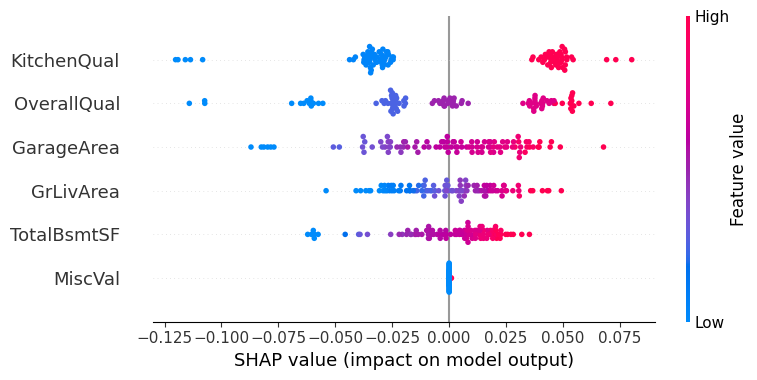

In [44]:
shap.summary_plot(shap_values_uta, X_uta_test)

Every feature is of a gain type and is monotonic

plot indicates that the model's predictions are driven mostly by KitchenQual and OverallQual (high values increase predictions, low values decrease them), with GarageArea, GrLivArea, and TotalBsmtSF showing similar but weaker positive at high value effects, while MiscVal has almost no impact.
